# 3.2 Feature Engineering Notebook

Experiments organized by **dataset version**: binary AHI ≥ 5, binary AHI ≥ 15, and multiclass/ordinal 4-class severity. GCP integration for artifact tracking and lineage visualization.

## 1. Setup
Imports, GCP/GCS configuration, Vertex AI experiment names, tuning hyperparameters, and SDK initialization.

In [1]:
# ── standard library ─────────────────────────────────────────────────────────
import re
import sys
import json
import datetime
from contextlib import contextmanager
from pathlib import Path
from types import SimpleNamespace

# ── data & numeric ────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# ── ML ────────────────────────────────────────────────────────────────────────
import gcsfs
import joblib
import mord
import lightgbm as lgb
from imblearn.ensemble import BalancedRandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    roc_auc_score,
    f1_score,
    roc_curve,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

# ── GCP ───────────────────────────────────────────────────────────────────────
from google.cloud import aiplatform

# ── project ───────────────────────────────────────────────────────────────────
from src.modeling.eval import evaluate_binary as evaluate, evaluate_multiclass as evaluate_mc, tag_comparison_df as _tag
from src.features import raw_data_loader, feature_encoder
from src.features.transformers import Factor_Analyzer_Transformer
from src.modeling.fa_tuning import tune_factor_analysis_rotation, build_best_factor_analysis_pipeline
from src.utils.data_utils import convert_ahi, make_multiclass_y


In [2]:
# ── GCP core ─────────────────────────────────────────────────────────────────
PROJECT_ID = "apnea-detection-494320"
LOCATION   = "us-central1"
BUCKET_URI = "gs://apnea-detector-bucket"


In [3]:
# ── GCS artifact paths ────────────────────────────────────────────────────────
BEST_PARAMS_PATH        = "../../data/interim/best_fa_xgb_params.json"
BEST_MODEL_DIR_URI      = f"{BUCKET_URI}/models/best-fa-xgb-pipeline/"
BEST_MODEL_GCS_URI      = f"{BEST_MODEL_DIR_URI}model.joblib"
TRIAL_RESULTS_URI       = f"{BUCKET_URI}/tuning/trial-results.csv"
FA_DATASET_URI          = f"{BUCKET_URI}/datasets/fa-transformed-train.csv"
BINARY_AHI5_COMPARISON_URI  = f"{BUCKET_URI}/comparisons/binary-ahi5-comparison.csv"
THRESHOLD_SWEEP_URI         = f"{BUCKET_URI}/comparisons/ahi-threshold-sweep.csv"
MC_COMPARISON_URI           = f"{BUCKET_URI}/comparisons/multiclass-4class-comparison.csv"
BINARY_AHI15_COMPARISON_URI = f"{BUCKET_URI}/comparisons/binary-ahi15-comparison.csv"
ORDINAL_COMPARISON_URI      = f"{BUCKET_URI}/comparisons/ordinal-comparison.csv"
OVERALL_SUMMARY_URI         = f"{BUCKET_URI}/comparisons/overall-summary.csv"
BEST_PER_APPROACH_URI       = f"{BUCKET_URI}/comparisons/best-per-approach.csv"


In [4]:
# ── Vertex AI experiment names ────────────────────────────────────────────────
TUNING_EXPERIMENT          = "3-2-fa-xgb-tuning"
BINARY_AHI5_EXPERIMENT     = "3-2-binary-ahi5-comparison"
THRESHOLD_SWEEP_EXPERIMENT = "3-2-ahi-threshold-sweep"
MULTICLASS_EXPERIMENT      = "3-2-multiclass-4class"
BINARY_AHI15_EXPERIMENT    = "3-2-binary-ahi15-comparison"
ORDINAL_EXPERIMENT         = "3-2-ordinal-comparison"
OVERALL_SUMMARY_EXPERIMENT = "3-2-overall-summary"

# ── Session identity — shared across all runs in this notebook execution ──────
NOTEBOOK_VERSION = "3.2"
SESSION_TS = datetime.datetime.now(datetime.timezone.utc).strftime("%Y%m%d-%H%M%S")
print(f"Session: {SESSION_TS}  |  Notebook version: {NOTEBOOK_VERSION}")


Session: 20260425-021629  |  Notebook version: 3.2


In [5]:
# ── Model Registry serving containers ────────────────────────────────────────
SKLEARN_CONTAINER = "us-docker.pkg.dev/vertex-ai/prediction/sklearn-cpu.1-3:latest"
XGBOOST_CONTAINER = "us-docker.pkg.dev/vertex-ai/prediction/xgboost-cpu.1-5:latest"

# ── Hyperparameter tuning ─────────────────────────────────────────────────────
TUNING_SCORING = "average_precision"
FORCE_RETUNE   = False
_SCORING_TO_COL = {
    "roc_auc": "roc_auc", "average_precision": "avg_precision",
    "f1_macro": "f1_macro", "f1": "f1_macro", "accuracy": "accuracy",
}
SORT_METRIC    = _SCORING_TO_COL.get(TUNING_SCORING, "avg_precision")
SORT_METRIC_MC = "avg_precision_ovr" if SORT_METRIC == "avg_precision" else SORT_METRIC

xgb_search_space = {
    "n_estimators":     {"type": "int",   "low": 100,  "high": 500,  "step": 50},
    "max_depth":        {"type": "int",   "low": 3,    "high": 8},
    "min_child_weight": {"type": "int",   "low": 1,    "high": 10},
    "learning_rate":    {"type": "float", "low": 0.01, "high": 0.3,  "log": True},
    "subsample":        {"type": "float", "low": 0.6,  "high": 1.0,  "step": 0.1},
    "colsample_bytree": {"type": "float", "low": 0.6,  "high": 1.0,  "step": 0.1},
    "gamma":            {"type": "float", "low": 0.0,  "high": 5.0,  "step": 0.5},
}
rotations = ["varimax", "promax", "oblimin", "oblimax", "quartimin", "quartimax", "equamax"]

PY_VER = f"{sys.version_info.major}.{sys.version_info.minor}"
print(f"Python {PY_VER}  |  Project: {PROJECT_ID}  |  Location: {LOCATION}")
print(f"SORT_METRIC={SORT_METRIC}  |  TUNING_SCORING={TUNING_SCORING}  |  FORCE_RETUNE={FORCE_RETUNE}")


Python 3.12  |  Project: apnea-detection-494320  |  Location: us-central1
SORT_METRIC=avg_precision  |  TUNING_SCORING=average_precision  |  FORCE_RETUNE=False


In [6]:
aiplatform.init(project=PROJECT_ID, location=LOCATION, staging_bucket=BUCKET_URI)
print(f"Vertex AI SDK initialized  |  project={PROJECT_ID}  |  location={LOCATION}")

Vertex AI SDK initialized  |  project=apnea-detection-494320  |  location=us-central1


## 2. Data & Feature Preparation
Load raw data, apply feature encoding, create all train/test splits, tune FA rotation, and register canonical dataset artifacts in Vertex AI Metadata.

### 2.1 Data Ingestion — Load, Split & Class Weights

In [7]:
raw_df = raw_data_loader.load_and_clean_raw("../..")
df = feature_encoder.encode_features(raw_df)
df = df.drop(columns=["ess_total_score", "isi_total_score"])

X = df.drop(columns=["ahi"])
y = convert_ahi(df["ahi"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
print(f"Train — negative: {neg}, positive: {pos}, prevalence: {pos / len(y_train):.1%}")

Train — negative: 459, positive: 890, prevalence: 66.0%


In [8]:
# ── class balance (binary AHI≥5) ─────────────────────────────────────────────
spw = float(neg) / float(pos)  # scale_pos_weight
print(f"Binary AHI≥5  — spw={spw:.2f}  |  SORT_METRIC={SORT_METRIC}")

# ── multiclass split (4-class: none / mild / moderate / severe) ───────────────
MC_NAMES = ["none", "mild", "moderate", "severe"]
X_mc = df.drop(columns=["ahi"])
y_mc = make_multiclass_y(df["ahi"])
Xtr_mc, Xte_mc, ytr_mc, yte_mc = train_test_split(
    X_mc, y_mc, test_size=0.2, random_state=42, stratify=y_mc
)

# ── binary AHI≥15 split ───────────────────────────────────────────────────────
X_15 = df.drop(columns=["ahi"])
y_15 = convert_ahi(df["ahi"], threshold=15)
Xtr15, Xte15, ytr15, yte15 = train_test_split(
    X_15, y_15, test_size=0.2, random_state=42, stratify=y_15
)
neg15, pos15 = (ytr15 == 0).sum(), (ytr15 == 1).sum()
spw15 = float(neg15) / float(pos15)
print(f"Binary AHI≥15 — neg: {neg15}, pos: {pos15}, prevalence={pos15/(neg15+pos15):.1%}, spw={spw15:.2f}")


Binary AHI≥5  — spw=0.52  |  SORT_METRIC=avg_precision
Binary AHI≥15 — neg: 888, pos: 461, prevalence=34.2%, spw=1.93


### 2.2 Vertex AI Utilities
Shared helpers: `register_artifact`, `save_model_to_gcs`, `tracked_run`, `get_run_results`.

In [9]:
def register_artifact(schema_title: str, display_name: str, uri: str, metadata: dict | None = None) -> aiplatform.Artifact:
    """Create and register a Vertex AI Metadata artifact.

    Args:
        schema_title: Vertex schema, e.g. "system.Dataset" or "system.Model".
        display_name: Human-readable name shown in the Vertex console.
        uri: GCS URI where the artifact is stored.
        metadata: Optional dict of extra metadata fields.

    Returns:
        The registered Artifact object.
    """
    kwargs = dict(schema_title=schema_title, display_name=display_name, uri=uri)
    if metadata:
        kwargs["metadata"] = metadata
    return aiplatform.Artifact.create(**kwargs)


def save_model_to_gcs(model, gcs_uri: str) -> None:
    """Serialise a model with joblib and write it to GCS."""
    with fs.open(gcs_uri, "wb") as f:
        joblib.dump(model, f)


fs = gcsfs.GCSFileSystem(project=PROJECT_ID)


In [10]:
@contextmanager
def tracked_run(
    experiment_name: str,
    run_name: str,
    params: dict,
    input_artifacts: list | None = None,
):
    """Context manager that wires up a Vertex AI Experiment run with lineage tracking.

    Usage::

        with tracked_run("my-experiment", "run-1", params, input_artifacts=[ds_art]) as execution:
            # train / evaluate here
            aiplatform.log_metrics({"roc_auc": 0.85})
            execution.assign_output_artifacts([model_art])

    Handles:
    - aiplatform.init with the experiment
    - start_run / end_run lifecycle
    - start_execution context with input artifact assignment
    - param logging (always includes notebook_version and session_ts)
    """
    aiplatform.init(
        project=PROJECT_ID, location=LOCATION,
        staging_bucket=BUCKET_URI, experiment=experiment_name,
    )
    aiplatform.start_run(run_name)

    enriched_params = {"notebook_version": NOTEBOOK_VERSION, "session_ts": SESSION_TS, **params}
    aiplatform.log_params(enriched_params)

    with aiplatform.start_execution(
        schema_title="system.ContainerExecution",
        display_name=run_name,
    ) as execution:
        if input_artifacts:
            execution.assign_input_artifacts(input_artifacts)
        try:
            yield execution
        finally:
            aiplatform.end_run()


In [11]:
def get_run_results(experiment_name: str) -> "pd.DataFrame":
    """Fetch all runs for *experiment_name* from Vertex AI and return as a DataFrame."""
    exp_df = aiplatform.get_experiment_df()
    run_df = exp_df[exp_df["experiment_name"] == experiment_name].copy()
    return run_df

### 2.3 Feature Engineering — FA + XGBoost Tuning
Optuna hyperparameter search over FA rotation + XGBoost params, ported from 2.3. Results are cached to disk; set `FORCE_RETUNE = True` in the config cell to re-run.

In [12]:
# Tuning configuration is defined in the config cell above.
print(f"  xgb_search_space keys : {list(xgb_search_space)}")
print(f"  rotations             : {rotations}")
print(f"  TUNING_SCORING        : {TUNING_SCORING}")
print(f"  FORCE_RETUNE          : {FORCE_RETUNE}")

  xgb_search_space keys : ['n_estimators', 'max_depth', 'min_child_weight', 'learning_rate', 'subsample', 'colsample_bytree', 'gamma']
  rotations             : ['varimax', 'promax', 'oblimin', 'oblimax', 'quartimin', 'quartimax', 'equamax']
  TUNING_SCORING        : average_precision
  FORCE_RETUNE          : False


In [13]:
if FORCE_RETUNE or not Path(BEST_PARAMS_PATH).exists():
    tuning_result = tune_factor_analysis_rotation(
        X, y,
        rotations=rotations,
        n_factors=18,
        n_splits=5,
        n_trials=40,
        scoring=TUNING_SCORING,
        xgb_search_space=xgb_search_space,
        random_state=42,
    )

    best_xgb_params = {k: v for k, v in tuning_result.best_params.items() if k not in {"rotation", "n_factors"}}

    # ── fit best pipeline on full training data ───────────────────────────────
    best_fa_pipeline = build_best_factor_analysis_pipeline(
        SimpleNamespace(
            best_params=tuning_result.best_params,
            best_rotation=tuning_result.best_rotation,
            best_method=tuning_result.best_params.get("method"),
        )
    )
    best_fa_pipeline.fit(X_train, y_train)
    save_model_to_gcs(best_fa_pipeline, BEST_MODEL_GCS_URI)

    # ── save trial results CSV to GCS ─────────────────────────────────────────
    with fs.open(TRIAL_RESULTS_URI, "w") as f:
        tuning_result.trial_results.to_csv(f, index=False)

    # ── register artifacts ────────────────────────────────────────────────────
    tuning_params = {
        "scoring":              TUNING_SCORING,
        "n_splits":             5,
        "n_trials":             40,
        "fixed_n_factors":      18,
        "candidate_rotations":  ",".join(rotations),
        "best_rotation":        tuning_result.best_rotation,
        "best_n_factors":       tuning_result.best_params.get("n_factors", 18),
        **{f"best_{k}": v for k, v in best_xgb_params.items()},
    }

    dataset_art = register_artifact(
        "system.Dataset",
        "apnea-dataset-raw",
        f"{BUCKET_URI}/processed_data.csv",
    )
    model_art = register_artifact(
        "system.Model",
        "best-fa-xgb-pipeline",
        metadata={
            "rotation":   tuning_result.best_rotation,
            "n_factors":  tuning_result.best_params.get("n_factors", 18),
            "scoring":    TUNING_SCORING,
            "best_score": round(float(tuning_result.best_score), 4),
        },
    )
    trial_art = register_artifact(
        "system.Dataset",
        "tuning-trial-results",
        metadata={"n_trials": len(tuning_result.trial_results)},
    )

    with tracked_run(TUNING_EXPERIMENT, f"fa-xgb-optuna-search-{SESSION_TS}", tuning_params, input_artifacts=[dataset_art]) as execution:
        # ── summary metrics ───────────────────────────────────────────────────
        aiplatform.log_metrics({
            f"best_mean_cv_{TUNING_SCORING}": round(float(tuning_result.best_score), 4),
            "completed_trials":               float(len(tuning_result.trial_results)),
        })

        # ── per-rotation best CV scores ───────────────────────────────────────
        rotation_metrics = {
            f"cv_{row['rotation']}": round(float(row["best_score"]), 4)
            for _, row in tuning_result.rotation_summary.reset_index().iterrows()
        }
        aiplatform.log_metrics(rotation_metrics)

        # ── trial distribution stats ──────────────────────────────────────────
        scores = tuning_result.trial_results["mean_score"]
        aiplatform.log_metrics({
            "trial_score_mean": round(float(scores.mean()), 4),
            "trial_score_std":  round(float(scores.std()),  4),
            "trial_score_min":  round(float(scores.min()),  4),
            "trial_score_max":  round(float(scores.max()),  4),
        })

        execution.assign_output_artifacts([model_art, trial_art])

    # ── upload to Vertex AI Model Registry ───────────────────────────────────
    registered_model = aiplatform.Model.upload(
        display_name="best-fa-xgb-pipeline",
        artifact_uri=BEST_MODEL_DIR_URI,
        serving_container_image_uri=SKLEARN_CONTAINER,
        labels={
            "rotation":  tuning_result.best_rotation,
            "n_factors": str(tuning_result.best_params.get("n_factors", 18)),
        },
    )
    print(f"Model Registry resource: {registered_model.resource_name}")

    # ── cache params to disk ──────────────────────────────────────────────────
    with open(BEST_PARAMS_PATH, "w") as f:
        json.dump(tuning_result.best_params, f, indent=2)

    print(f"Best rotation:   {tuning_result.best_rotation}")
    print(f"Best n_factors:  {tuning_result.best_params.get('n_factors', 18)}")
    print(f"Best CV {TUNING_SCORING}: {tuning_result.best_score:.4f}")
    print(tuning_result.rotation_summary)

# ── always load from disk so downstream cells work ────────────────────────────
with open(BEST_PARAMS_PATH) as f:
    _saved_params = json.load(f)

# ── always register the raw dataset artifact (needed by downstream cells) ─────
dataset_art = register_artifact(
    "system.Dataset",
    "apnea-dataset-raw",
    f"{BUCKET_URI}/processed_data.csv",
)

best_fa_pipeline = build_best_factor_analysis_pipeline(
    SimpleNamespace(
        best_params=_saved_params,
        best_rotation=_saved_params.get("rotation"),
        best_method=_saved_params.get("method"),
    )
)
best_xgb_params = {k: v for k, v in _saved_params.items() if k not in {"rotation", "n_factors"}}

print(f"Loaded best_rotation : {_saved_params.get('rotation')}")
print(f"Loaded best_n_factors: {_saved_params.get('n_factors', 18)}")
print(f"Loaded XGBoost params: {best_xgb_params}")


Loaded best_rotation : quartimax
Loaded best_n_factors: 18
Loaded XGBoost params: {'method': 'minres', 'n_estimators': 350, 'max_depth': 3, 'min_child_weight': 5, 'learning_rate': 0.033331461562247956, 'subsample': 0.7, 'colsample_bytree': 0.9, 'gamma': 4.0}


### 2.4 FA-Transformed Dataset Artifact
Transform training data with the best-tuned FA rotation and register in Vertex AI Metadata for lineage tracking.

In [14]:
# Fit a standalone FA transformer on training data using best-tuned params
_fa_art = Factor_Analyzer_Transformer(
    rotation=_saved_params.get("rotation", "varimax"),
    n_factors=_saved_params.get("n_factors", 18),
)
fa_df = _fa_art.fit_transform(X_train).copy()
fa_df.insert(0, "target", y_train.values)

with fs.open(FA_DATASET_URI, "w") as f:
    fa_df.to_csv(f, index=False)

fa_dataset_art = register_artifact(
    "system.Dataset", "fa-transformed-train", FA_DATASET_URI,
    metadata={
        "n_factors": _saved_params.get("n_factors", 18),
        "rotation": _saved_params.get("rotation", "varimax"),
        "n_samples": len(fa_df),
    },
)
print(f"Registered: {fa_dataset_art.resource_name}")
print(f"Shape: {fa_df.shape}")


Registered: projects/257684551037/locations/us-central1/metadataStores/default/artifacts/e15d9e06-b915-49b7-afdb-618f4f09fbdc
Shape: (1349, 19)


## 3. Dataset v1 — Binary AHI ≥ 5
Standard OSA threshold. Dummy baseline, standalone SMOTE + FA(18), then a 6-model sweep with optimal threshold tuning.

### 3.1 Model Comparison
Dummy baseline, SMOTE + FA(18), and a 6-model sweep with Youden-optimal threshold tuning.

In [15]:
# ── dummy classifier ──────────────────────────────────────────────────────────
dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train, y_train)
dummy_preds = dummy_clf.predict(X_test)
dummy_acc = float(accuracy_score(y_test, dummy_preds))

with tracked_run(BINARY_AHI5_EXPERIMENT, f"dummy-classifier-{SESSION_TS}",
                 params={"model": "DummyClassifier", "strategy": "most_frequent"},
                 input_artifacts=[dataset_art]) as _exec:
    aiplatform.log_metrics({"accuracy": round(dummy_acc, 4)})

print(f"Dummy accuracy: {dummy_acc:.4f}")
print(classification_report(y_test, dummy_preds))

# ── standalone SMOTE + FA(18) + XGBoost ───────────────────────────────────────
_smote_fa = Factor_Analyzer_Transformer(rotation="varimax", n_factors=18)
X_tr_smote_fa = _smote_fa.fit_transform(X_train)
X_te_smote_fa = _smote_fa.transform(X_test)
X_sm, y_sm = SMOTE(random_state=42).fit_resample(X_tr_smote_fa, y_train)
smote_clf = XGBClassifier(n_estimators=250, max_depth=4, random_state=42)
smote_clf.fit(X_sm, y_sm)
smote_preds = smote_clf.predict(X_te_smote_fa)
smote_proba = smote_clf.predict_proba(X_te_smote_fa)
smote_roc = float(roc_auc_score(y_test, smote_proba[:, 1]))
smote_acc = float(accuracy_score(y_test, smote_preds))

with tracked_run(BINARY_AHI5_EXPERIMENT, f"smote-fa-xgb-{SESSION_TS}",
                 params={"pipeline": "smote-fa-xgb", "rotation": "varimax",
                         "n_factors": 18, "n_estimators": 250, "max_depth": 4},
                 input_artifacts=[dataset_art, fa_dataset_art]) as _exec:
    aiplatform.log_metrics({"roc_auc": round(smote_roc, 4), "accuracy": round(smote_acc, 4)})

print(f"\nSMOTE + FA(18) + XGBoost — ROC-AUC: {smote_roc:.4f}  |  Accuracy: {smote_acc:.4f}")
print(classification_report(y_test, smote_preds))


Associating projects/257684551037/locations/us-central1/metadataStores/default/contexts/3-2-binary-ahi5-comparison-dummy-classifier-20260425-021629 to Experiment: 3-2-binary-ahi5-comparison


Dummy accuracy: 0.6598
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       115
           1       0.66      1.00      0.80       223

    accuracy                           0.66       338
   macro avg       0.33      0.50      0.40       338
weighted avg       0.44      0.66      0.52       338



/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(r

Associating projects/257684551037/locations/us-central1/metadataStores/default/contexts/3-2-binary-ahi5-comparison-smote-fa-xgb-20260425-021629 to Experiment: 3-2-binary-ahi5-comparison



SMOTE + FA(18) + XGBoost — ROC-AUC: 0.5123  |  Accuracy: 0.5385
              precision    recall  f1-score   support

           0       0.36      0.48      0.41       115
           1       0.68      0.57      0.62       223

    accuracy                           0.54       338
   macro avg       0.52      0.52      0.52       338
weighted avg       0.57      0.54      0.55       338



In [16]:
results = []
model_store = []  # parallel list: (model_obj, X_for_predict)

# 1. Raw XGBoost
m = XGBClassifier(n_estimators=250, max_depth=4, random_state=42, eval_metric="logloss")
m.fit(X_train, y_train)
model_store.append((m, X_test))
results.append(evaluate("1. Raw XGBoost (no FA)", y_test, m.predict(X_test), m.predict_proba(X_test)))

# 2. XGBoost + scale_pos_weight
m = XGBClassifier(n_estimators=250, max_depth=4, random_state=42, scale_pos_weight=spw, eval_metric="logloss")
m.fit(X_train, y_train)
model_store.append((m, X_test))
results.append(evaluate("2. XGBoost + scale_pos_weight (no FA)", y_test, m.predict(X_test), m.predict_proba(X_test)))

# 3. FA(18) + XGBoost + scale_pos_weight
m = Pipeline([
    ("fa",  Factor_Analyzer_Transformer(rotation="varimax", n_factors=18)),
    ("clf", XGBClassifier(n_estimators=250, max_depth=4, random_state=42, scale_pos_weight=spw, eval_metric="logloss")),
])
m.fit(X_train, y_train)
model_store.append((m, X_test))
results.append(evaluate("3. FA(18) + XGBoost + scale_pos_weight", y_test, m.predict(X_test), m.predict_proba(X_test)))

# 4. FA(6 top SHAP factors) + XGBoost + scale_pos_weight
m = Pipeline([
    ("fa",  Factor_Analyzer_Transformer(rotation="varimax", n_factors=6)),
    ("clf", XGBClassifier(n_estimators=250, max_depth=4, random_state=42, scale_pos_weight=spw, eval_metric="logloss")),
])
m.fit(X_train, y_train)
model_store.append((m, X_test))
results.append(evaluate("4. FA(6) + XGBoost + scale_pos_weight", y_test, m.predict(X_test), m.predict_proba(X_test)))

# 5. SMOTE + FA(18) + XGBoost (clean re-run)
_sfa = Factor_Analyzer_Transformer(rotation="varimax", n_factors=18)
Xtr_s = _sfa.fit_transform(X_train)
Xte_s = _sfa.transform(X_test)
Xr, yr = SMOTE(random_state=42).fit_resample(Xtr_s, y_train)
m = XGBClassifier(n_estimators=250, max_depth=4, random_state=42, eval_metric="logloss")
m.fit(Xr, yr)
model_store.append((m, Xte_s))
results.append(evaluate("5. SMOTE + FA(18) + XGBoost (baseline)", y_test, m.predict(Xte_s), m.predict_proba(Xte_s)))

# 6. BalancedRandomForest — handles imbalance natively, no FA
m = BalancedRandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
m.fit(X_train, y_train)
model_store.append((m, X_test))
results.append(evaluate("6. BalancedRandomForest (no FA)", y_test, m.predict(X_test), m.predict_proba(X_test)))

# ── optimal threshold on best model ──────────────────────────────────────────
best_idx = int(pd.DataFrame(results)[SORT_METRIC].idxmax())
best_obj, best_Xp = model_store[best_idx]
best_proba = best_obj.predict_proba(best_Xp)[:, 1]
fpr_b, tpr_b, thresh_b = roc_curve(y_test, best_proba)
best_thresh = float(thresh_b[(tpr_b - fpr_b).argmax()])
results.append(evaluate(
    f"7. {results[best_idx]['model'].split('. ', 1)[1]} + thresh={best_thresh:.2f}",
    y_test, (best_proba >= best_thresh).astype(int),
    best_obj.predict_proba(best_Xp), threshold=best_thresh,
))

results_df = pd.DataFrame(results).sort_values(SORT_METRIC, ascending=False).reset_index(drop=True)
winner = results_df.iloc[0]

# ── save comparison CSV to GCS + register ────────────────────────────────────
with fs.open(BINARY_AHI5_COMPARISON_URI, "w") as f:
    results_df.to_csv(f, index=False)
comparison_art = register_artifact(
    "system.Dataset", "binary-ahi5-comparison", BINARY_AHI5_COMPARISON_URI,
    metadata={"n_models": len(results_df)},
)

with tracked_run(BINARY_AHI5_EXPERIMENT, f"model-comparison-{SESSION_TS}",
                 params={"best_model": winner["model"],
                         "best_threshold": round(float(winner["threshold"]), 4),
                         "sort_metric": SORT_METRIC},
                 input_artifacts=[dataset_art]) as _exec:
    aiplatform.log_metrics({
        f"best_{SORT_METRIC}": round(float(winner[SORT_METRIC]), 4),
        "best_accuracy": round(float(winner["accuracy"]), 4),
        "best_f1_macro": round(float(winner["f1_macro"]), 4),
    })
    _exec.assign_output_artifacts([comparison_art])

print("\n" + "=" * 58)
print(f"  MODEL COMPARISON SUMMARY (sorted by {SORT_METRIC.upper()})")
print("=" * 58)
display(results_df)



──────────────────────────────────────────────────────────
  1. Raw XGBoost (no FA)
──────────────────────────────────────────────────────────
  Avg-Prec: 0.6742  |  ROC-AUC : 0.5062  |  Accuracy : 0.6154  |  F1-macro : 0.4970  (thresh=0.50)
              precision    recall  f1-score   support

    no_apnea       0.37      0.19      0.25       115
       apnea       0.67      0.83      0.74       223

    accuracy                           0.62       338
   macro avg       0.52      0.51      0.50       338
weighted avg       0.57      0.62      0.57       338


──────────────────────────────────────────────────────────
  2. XGBoost + scale_pos_weight (no FA)
──────────────────────────────────────────────────────────
  Avg-Prec: 0.6428  |  ROC-AUC : 0.4709  |  Accuracy : 0.5680  |  F1-macro : 0.4846  (thresh=0.50)
              precision    recall  f1-score   support

    no_apnea       0.32      0.24      0.28       115
       apnea       0.65      0.74      0.69       223

    accu

I0424 19:17:08.727350 34231405 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0424 19:17:08.736904 34232726 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(97, generation: 1)
I0424 19:17:08.737014 34232726 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(95, generation: 1)
I0424 19:17:08.737021 34232726 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(93, generation: 1)
I0424 19:17:08.737022 34232726 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(89, generation: 1)
I0424 19:17:08.737023 34232726 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(94, generation: 1)
I0424 19:17:08.737024 34232726 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(92, generation: 1)
I0424 19:17:08.737025 34232726 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(91, generation: 1)
I0424 19:17:08.737025 34232726 ev_poll_posix.cc:593] FD from fork parent s


──────────────────────────────────────────────────────────
  6. BalancedRandomForest (no FA)
──────────────────────────────────────────────────────────
  Avg-Prec: 0.6652  |  ROC-AUC : 0.4980  |  Accuracy : 0.5799  |  F1-macro : 0.4958  (thresh=0.50)
              precision    recall  f1-score   support

    no_apnea       0.34      0.25      0.29       115
       apnea       0.66      0.75      0.70       223

    accuracy                           0.58       338
   macro avg       0.50      0.50      0.50       338
weighted avg       0.55      0.58      0.56       338


──────────────────────────────────────────────────────────
  7. Raw XGBoost (no FA) + thresh=0.77
──────────────────────────────────────────────────────────
  Avg-Prec: 0.6742  |  ROC-AUC : 0.5062  |  Accuracy : 0.5592  |  F1-macro : 0.5294  (thresh=0.77)
              precision    recall  f1-score   support

    no_apnea       0.38      0.45      0.41       115
       apnea       0.69      0.61      0.65       223



Associating projects/257684551037/locations/us-central1/metadataStores/default/contexts/3-2-binary-ahi5-comparison-model-comparison-20260425-021629 to Experiment: 3-2-binary-ahi5-comparison



  MODEL COMPARISON SUMMARY (sorted by AVG_PRECISION)


,model,avg_precision,roc_auc,accuracy,f1_macro,threshold
0,1. Raw XGBoost (no FA),0.6742,0.5062,0.6154,0.4970,0.500000
1,7. Raw XGBoost (no FA) + thresh=0.77,0.6742,0.5062,0.5592,0.5294,0.766551
2,3. FA(18) + XGBoost + scale_pos_weight,0.6671,0.5400,0.5385,0.5190,0.500000
3,6. BalancedRandomForest (no FA),0.6652,0.4980,0.5799,0.4958,0.500000
4,5. SMOTE + FA(18) + XGBoost (baseline),0.6495,0.5123,0.5385,0.5165,0.500000
5,4. FA(6) + XGBoost + scale_pos_weight,0.6450,0.5156,0.5355,0.5128,0.500000
6,2. XGBoost + scale_pos_weight (no FA),0.6428,0.4709,0.5680,0.4846,0.500000


### 3.2 AHI Threshold Sweep
FA(18) + XGBoost + scale_pos_weight evaluated at AHI cut-offs 5, 15, and 30. Mirrors the 2.3 sweep.

In [17]:
THRESHOLDS = [5, 15, 30]

ahi_raw = df["ahi"]
thresh_rows = []

with tracked_run(THRESHOLD_SWEEP_EXPERIMENT, f"ahi-threshold-sweep-{SESSION_TS}",
                 params={"thresholds": ",".join(str(t) for t in THRESHOLDS),
                         "model": "FA18-XGB-scale-pos-weight",
                         "rotation": "varimax", "n_factors": 18},
                 input_artifacts=[dataset_art]) as _exec:
    sweep_metrics = {}
    for thresh in THRESHOLDS:
        y_t = convert_ahi(ahi_raw, threshold=thresh)
        pos_t = y_t.sum()
        neg_t = len(y_t) - pos_t
        prev = pos_t / len(y_t)

        _sp = train_test_split(X, y_t, test_size=0.2, random_state=42, stratify=y_t)
        Xtr_t, Xte_t, ytr_t, yte_t = _sp[0], _sp[1], _sp[2], _sp[3]
        spw_t = float((ytr_t == 0).sum()) / float((ytr_t == 1).sum()) if (ytr_t == 1).sum() > 0 else 1.0

        pipe_t = Pipeline([
            ("fa",  Factor_Analyzer_Transformer(rotation="varimax", n_factors=18)),
            ("clf", XGBClassifier(n_estimators=250, max_depth=4, random_state=42,
                                  scale_pos_weight=spw_t, eval_metric="logloss")),
        ])
        pipe_t.fit(Xtr_t, ytr_t)
        proba_t = pipe_t.predict_proba(Xte_t)[:, 1]
        preds_t = pipe_t.predict(Xte_t)

        ap   = float(average_precision_score(yte_t, proba_t))
        auc  = float(roc_auc_score(yte_t, proba_t))
        acc  = float(accuracy_score(yte_t, preds_t))
        f1m  = float(f1_score(yte_t, preds_t, average="macro"))
        prev_f = float(prev)

        sweep_metrics[f"avg_precision_thresh{thresh}"] = round(ap, 4)
        sweep_metrics[f"roc_auc_thresh{thresh}"]       = round(auc, 4)
        sweep_metrics[f"accuracy_thresh{thresh}"]      = round(acc, 4)
        sweep_metrics[f"f1_macro_thresh{thresh}"]      = round(f1m, 4)
        sweep_metrics[f"prevalence_thresh{thresh}"]    = round(prev_f, 4)

        thresh_rows.append({
            "ahi_threshold": thresh, "label": f"AHI≥{thresh}",
            "n_positive": int(pos_t), "n_negative": int(neg_t),
            "prevalence": round(prev_f, 3),
            "avg_precision": round(ap, 4), "roc_auc": round(auc, 4),
            "accuracy": round(acc, 4), "f1_macro": round(f1m, 4),
        })
        print(f"\n{'─'*58}")
        print(f"  AHI threshold = {thresh}  (positive={pos_t}, prevalence={prev_f:.1%})")
        print(f"{'─'*58}")
        print(classification_report(yte_t, preds_t, target_names=["negative", "apnea"]))

    thresh_df = pd.DataFrame(thresh_rows)
    aiplatform.log_metrics(sweep_metrics)

    with fs.open(THRESHOLD_SWEEP_URI, "w") as f:
        thresh_df.to_csv(f, index=False)
    sweep_art = register_artifact(
        "system.Dataset", "ahi-threshold-sweep", THRESHOLD_SWEEP_URI,
        metadata={"n_thresholds": len(THRESHOLDS)},
    )
    _exec.assign_output_artifacts([sweep_art])

print("\n" + "=" * 58)
print("  AHI THRESHOLD SWEEP SUMMARY (FA18 + XGB + scale_pos_weight)")
print("=" * 58)
display(thresh_df)


Associating projects/257684551037/locations/us-central1/metadataStores/default/contexts/3-2-ahi-threshold-sweep-ahi-threshold-sweep-20260425-021629 to Experiment: 3-2-ahi-threshold-sweep



──────────────────────────────────────────────────────────
  AHI threshold = 5  (positive=1113, prevalence=66.0%)
──────────────────────────────────────────────────────────
              precision    recall  f1-score   support

    negative       0.37      0.50      0.42       115
       apnea       0.68      0.56      0.62       223

    accuracy                           0.54       338
   macro avg       0.53      0.53      0.52       338
weighted avg       0.58      0.54      0.55       338


──────────────────────────────────────────────────────────
  AHI threshold = 15  (positive=577, prevalence=34.2%)
──────────────────────────────────────────────────────────
              precision    recall  f1-score   support

    negative       0.61      0.50      0.55       222
       apnea       0.28      0.38      0.32       116

    accuracy                           0.46       338
   macro avg       0.45      0.44      0.44       338
weighted avg       0.50      0.46      0.47       338

,ahi_threshold,label,n_positive,n_negative,prevalence,avg_precision,roc_auc,accuracy,f1_macro
0,5,AHI≥5,1113,574,0.660,0.6671,0.5400,0.5385,0.5190
1,15,AHI≥15,577,1110,0.342,0.3222,0.4724,0.4586,0.4364
2,30,AHI≥30,261,1426,0.155,0.1763,0.5320,0.5799,0.4624


## 4. Dataset v2 — Binary AHI ≥ 15
Moderate-to-severe OSA threshold. Adds LightGBM to the comparison.

In [ ]:
res15 = []
store15 = {}  # label → (model_obj, X_for_predict)

# 1. Raw XGBoost
m = XGBClassifier(n_estimators=250, max_depth=4, random_state=42, eval_metric="logloss")
m.fit(Xtr15, ytr15)
store15["1. Raw XGBoost"] = (m, Xte15)
res15.append(evaluate("1. Raw XGBoost", yte15, m.predict(Xte15), m.predict_proba(Xte15)))

# 2. XGBoost + scale_pos_weight
m = XGBClassifier(n_estimators=250, max_depth=4, random_state=42, scale_pos_weight=spw15, eval_metric="logloss")
m.fit(Xtr15, ytr15)
store15["2. XGBoost + scale_pos_weight"] = (m, Xte15)
res15.append(evaluate("2. XGBoost + scale_pos_weight", yte15, m.predict(Xte15), m.predict_proba(Xte15)))

# 3. FA(18) + XGBoost + scale_pos_weight
m = Pipeline([
    ("fa",  Factor_Analyzer_Transformer(rotation="varimax", n_factors=18)),
    ("clf", XGBClassifier(n_estimators=250, max_depth=4, random_state=42, scale_pos_weight=spw15, eval_metric="logloss")),
])
m.fit(Xtr15, ytr15)
store15["3. FA(18) + XGBoost + scale_pos_weight"] = (m, Xte15)
res15.append(evaluate("3. FA(18) + XGBoost + scale_pos_weight", yte15, m.predict(Xte15), m.predict_proba(Xte15)))

# 4. SMOTE + FA(18) + XGBoost
_fa15 = Factor_Analyzer_Transformer(rotation="varimax", n_factors=18)
Xtr15_fa = _fa15.fit_transform(Xtr15)
Xte15_fa = _fa15.transform(Xte15)
Xr15, yr15 = SMOTE(random_state=42).fit_resample(Xtr15_fa, ytr15)
m = XGBClassifier(n_estimators=250, max_depth=4, random_state=42, eval_metric="logloss")
m.fit(Xr15, yr15)
store15["4. SMOTE + FA(18) + XGBoost"] = (m, Xte15_fa)
res15.append(evaluate("4. SMOTE + FA(18) + XGBoost", yte15, m.predict(Xte15_fa), m.predict_proba(Xte15_fa)))

# 5. BalancedRandomForest
m = BalancedRandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
m.fit(Xtr15, ytr15)
store15["5. BalancedRandomForest"] = (m, Xte15)
res15.append(evaluate("5. BalancedRandomForest", yte15, m.predict(Xte15), m.predict_proba(Xte15)))

# 6. LightGBM — is_unbalance handles class skew natively
m = lgb.LGBMClassifier(n_estimators=300, max_depth=4, random_state=42, is_unbalance=True, verbose=-1)
m.fit(Xtr15, ytr15)
store15["6. LightGBM (is_unbalance)"] = (m, Xte15)
res15.append(evaluate("6. LightGBM (is_unbalance)", yte15, m.predict(Xte15), m.predict_proba(Xte15)))

# ── optimal threshold on best model ──────────────────────────────────────────
_best15_label = max(res15, key=lambda r: r[SORT_METRIC])["model"]
best15_obj, best15_Xp = store15[_best15_label]
best15_proba = best15_obj.predict_proba(best15_Xp)[:, 1]
fpr15, tpr15, thresh15 = roc_curve(yte15, best15_proba)
best15_thresh = float(thresh15[(tpr15 - fpr15).argmax()])
res15.append(evaluate(
    f"7. {_best15_label.split('. ', 1)[1]} + thresh={best15_thresh:.2f}",
    yte15, (best15_proba >= best15_thresh).astype(int),
    best15_obj.predict_proba(best15_Xp), threshold=best15_thresh,
))

res15_df = pd.DataFrame(res15).sort_values(SORT_METRIC, ascending=False).reset_index(drop=True)
winner15 = res15_df.iloc[0]

# ── save + register ───────────────────────────────────────────────────────────
with fs.open(BINARY_AHI15_COMPARISON_URI, "w") as f:
    res15_df.to_csv(f, index=False)
ahi15_art = register_artifact(
    "system.Dataset", "binary-ahi15-comparison", BINARY_AHI15_COMPARISON_URI,
    metadata={"ahi_threshold": 15, "n_models": len(res15_df)},
)

with tracked_run(BINARY_AHI15_EXPERIMENT, f"binary-ahi15-comparison-{SESSION_TS}",
                 params={"ahi_threshold": 15, "best_model": winner15["model"],
                         "best_threshold": round(float(winner15["threshold"]), 4)},
                 input_artifacts=[dataset_art]) as _exec:
    aiplatform.log_metrics({
        f"best_{SORT_METRIC}": round(float(winner15[SORT_METRIC]), 4),
        "best_accuracy": round(float(winner15["accuracy"]), 4),
        "best_f1_macro": round(float(winner15["f1_macro"]), 4),
    })
    _exec.assign_output_artifacts([ahi15_art])

print("\n" + "=" * 58)
print(f"  AHI≥15 BINARY COMPARISON (sorted by {SORT_METRIC.upper()})")
print("=" * 58)
display(res15_df)


## 5. Dataset v3 — Multiclass & Ordinal (4-Class)
Labels: 0=none (<5), 1=mild (5–14), 2=moderate (15–29), 3=severe (≥30). Ports the 2.3 multiclass comparison.

### 5.1 Standard Multiclass Comparison
Raw XGBoost, FA(18) + XGBoost, SMOTE + FA(18) + XGBoost, BalancedRandomForest, and Dummy baseline.


──────────────────────────────────────────────────────────
  1. Raw XGBoost (no FA)
──────────────────────────────────────────────────────────
  Avg-Prec(OvR/macro): 0.2712  |  ROC-AUC(OvR): 0.5057  |  Acc: 0.3077  |  F1-macro: 0.2449
              precision    recall  f1-score   support

        none       0.34      0.43      0.38       115
        mild       0.36      0.41      0.38       108
    moderate       0.14      0.10      0.11        63
      severe       0.16      0.08      0.10        52

    accuracy                           0.31       338
   macro avg       0.25      0.25      0.24       338
weighted avg       0.28      0.31      0.29       338


──────────────────────────────────────────────────────────
  2. FA(18) + XGBoost
──────────────────────────────────────────────────────────
  Avg-Prec(OvR/macro): 0.2644  |  ROC-AUC(OvR): 0.5177  |  Acc: 0.3225  |  F1-macro: 0.2469
              precision    recall  f1-score   support

        none       0.39      0.46      0.

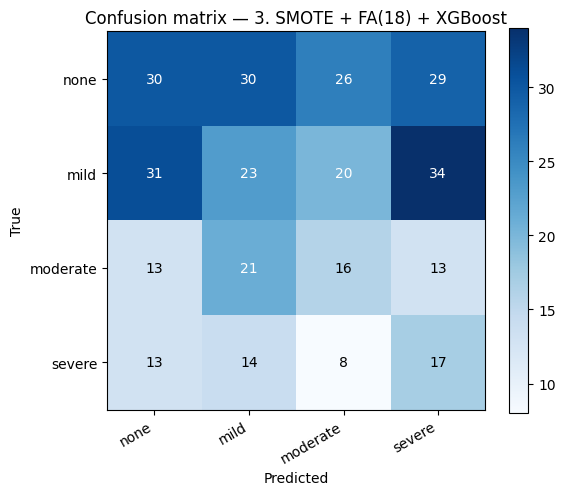

Associating projects/257684551037/locations/us-central1/metadataStores/default/contexts/3-2-multiclass-4class-multiclass-comparison-20260425-021629 to Experiment: 3-2-multiclass-4class



  MULTICLASS COMPARISON SUMMARY (sorted by AVG_PRECISION_OVR)


,model,avg_precision_ovr,roc_auc_ovr,accuracy,f1_macro
0,3. SMOTE + FA(18) + XGBoost,0.2713,0.5298,0.2544,0.2517
1,1. Raw XGBoost (no FA),0.2712,0.5057,0.3077,0.2449
2,2. FA(18) + XGBoost,0.2644,0.5177,0.3225,0.2469
3,5. Dummy (most_frequent),0.2500,0.5000,0.3402,0.1269
4,4. BalancedRandomForest (no FA),0.2480,0.4886,0.2604,0.2061


In [18]:
mc_results = []
mc_models  = []  # (fitted_model, X_for_predict)

# 1. Raw XGBoost
m1 = XGBClassifier(n_estimators=250, max_depth=4, random_state=42,
                   objective="multi:softprob", num_class=4, eval_metric="mlogloss")
m1.fit(Xtr_mc, ytr_mc)
mc_models.append((m1, Xte_mc))
mc_results.append(evaluate_mc("1. Raw XGBoost (no FA)", yte_mc, m1.predict(Xte_mc), m1.predict_proba(Xte_mc)))

# 2. FA(18) + XGBoost
m2 = Pipeline([
    ("fa",  Factor_Analyzer_Transformer(rotation="varimax", n_factors=18)),
    ("clf", XGBClassifier(n_estimators=250, max_depth=4, random_state=42,
                          objective="multi:softprob", num_class=4, eval_metric="mlogloss")),
])
m2.fit(Xtr_mc, ytr_mc)
mc_models.append((m2, Xte_mc))
mc_results.append(evaluate_mc("2. FA(18) + XGBoost", yte_mc, m2.predict(Xte_mc), m2.predict_proba(Xte_mc)))

# 3. SMOTE + FA(18) + XGBoost
_fa3 = Factor_Analyzer_Transformer(rotation="varimax", n_factors=18)
Xtr3 = _fa3.fit_transform(Xtr_mc)
Xte3 = _fa3.transform(Xte_mc)
Xr3, yr3 = SMOTE(random_state=42).fit_resample(Xtr3, ytr_mc)
m3 = XGBClassifier(n_estimators=250, max_depth=4, random_state=42,
                   objective="multi:softprob", num_class=4, eval_metric="mlogloss")
m3.fit(Xr3, yr3)
mc_models.append((m3, Xte3))
mc_results.append(evaluate_mc("3. SMOTE + FA(18) + XGBoost", yte_mc, m3.predict(Xte3), m3.predict_proba(Xte3)))

# 4. BalancedRandomForest
m4 = BalancedRandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
m4.fit(Xtr_mc, ytr_mc)
mc_models.append((m4, Xte_mc))
mc_results.append(evaluate_mc("4. BalancedRandomForest (no FA)", yte_mc, m4.predict(Xte_mc), m4.predict_proba(Xte_mc)))

# 5. Dummy baseline
m5 = DummyClassifier(strategy="most_frequent")
m5.fit(Xtr_mc, ytr_mc)
mc_models.append((m5, Xte_mc))
mc_results.append(evaluate_mc("5. Dummy (most_frequent)", yte_mc, m5.predict(Xte_mc), m5.predict_proba(Xte_mc)))

mc_results_df = pd.DataFrame(mc_results).sort_values(SORT_METRIC_MC, ascending=False).reset_index(drop=True)
mc_winner = mc_results_df.iloc[0]

# ── confusion matrix for the best model ──────────────────────────────────────
best_mc_idx = int(pd.DataFrame(mc_results)[SORT_METRIC_MC].idxmax())
cm_mc = confusion_matrix(yte_mc, np.asarray(mc_models[best_mc_idx][0].predict(mc_models[best_mc_idx][1])))
fig_mc, ax_mc = plt.subplots(figsize=(6, 5))
im_mc = ax_mc.imshow(cm_mc, cmap="Blues")
ax_mc.set_xticks(range(4)); ax_mc.set_yticks(range(4))
ax_mc.set_xticklabels(MC_NAMES, rotation=30, ha="right"); ax_mc.set_yticklabels(MC_NAMES)
ax_mc.set_xlabel("Predicted"); ax_mc.set_ylabel("True")
ax_mc.set_title(f"Confusion matrix — {mc_winner['model']}")
for i in range(4):
    for j in range(4):
        ax_mc.text(j, i, cm_mc[i, j], ha="center", va="center",
                   color="white" if cm_mc[i, j] > cm_mc.max() / 2 else "black")
plt.colorbar(im_mc, ax=ax_mc); plt.tight_layout(); plt.show()

# ── save + register ───────────────────────────────────────────────────────────
with fs.open(MC_COMPARISON_URI, "w") as f:
    mc_results_df.to_csv(f, index=False)
mc_art = register_artifact(
    "system.Dataset", "multiclass-4class-comparison", MC_COMPARISON_URI,
    metadata={"n_models": len(mc_results_df)},
)

with tracked_run(MULTICLASS_EXPERIMENT, f"multiclass-comparison-{SESSION_TS}",
                 params={"best_model": mc_winner["model"],
                         "label_scheme": "none<5/mild5-14/moderate15-29/severe30+"},
                 input_artifacts=[dataset_art]) as _exec:
    aiplatform.log_metrics({
        f"best_{SORT_METRIC_MC}": round(float(mc_winner[SORT_METRIC_MC]), 4),
        "best_accuracy": round(float(mc_winner["accuracy"]), 4),
        "best_f1_macro": round(float(mc_winner["f1_macro"]), 4),
    })
    _exec.assign_output_artifacts([mc_art])

print("\n" + "=" * 58)
print(f"  MULTICLASS COMPARISON SUMMARY (sorted by {SORT_METRIC_MC.upper()})")
print("=" * 58)
display(mc_results_df)


### 5.2 Ordinal Classification
`mord.LogisticAT` (All-Thresholds proportional-odds) on raw and FA(18) features, plus LightGBM multiclass.

In [20]:
# ── mord LogisticAT on raw features (needs scaling) ──────────────────────────
scaler_raw = StandardScaler()
Xtr_sc = scaler_raw.fit_transform(Xtr_mc)
Xte_sc = scaler_raw.transform(Xte_mc)
ord_raw = mord.LogisticAT(alpha=1.0)
ord_raw.fit(Xtr_sc, ytr_mc)
ord_raw_proba = ord_raw.predict_proba(Xte_sc)
ord_raw_preds = ord_raw.predict(Xte_sc)

# ── mord LogisticAT on FA(18) features ───────────────────────────────────────
_fa_ord = Factor_Analyzer_Transformer(rotation="varimax", n_factors=18)
Xtr_ord_fa = _fa_ord.fit_transform(Xtr_mc)
Xte_ord_fa = _fa_ord.transform(Xte_mc)
scaler_fa = StandardScaler()
Xtr_ord_fa_sc = scaler_fa.fit_transform(Xtr_ord_fa)
Xte_ord_fa_sc = scaler_fa.transform(Xte_ord_fa)
ord_fa = mord.LogisticAT(alpha=1.0)
ord_fa.fit(Xtr_ord_fa_sc, ytr_mc)
ord_fa_proba = ord_fa.predict_proba(Xte_ord_fa_sc)
ord_fa_preds = ord_fa.predict(Xte_ord_fa_sc)

# ── LightGBM multiclass ───────────────────────────────────────────────────────
lgb_mc = lgb.LGBMClassifier(n_estimators=300, max_depth=4, random_state=42,
                              is_unbalance=True, objective="multiclass", num_class=4, verbose=-1)
lgb_mc.fit(Xtr_mc, ytr_mc)
lgb_mc_proba = lgb_mc.predict_proba(Xte_mc)
lgb_mc_preds = lgb_mc.predict(Xte_mc)

ord_results = [
    evaluate_mc("mord LogisticAT (raw)",   yte_mc, ord_raw_preds, ord_raw_proba),
    evaluate_mc("mord LogisticAT (FA-18)", yte_mc, ord_fa_preds,  ord_fa_proba),
    evaluate_mc("LightGBM multiclass",      yte_mc, lgb_mc_preds,  lgb_mc_proba),
]
ord_df = pd.DataFrame(ord_results)

# ── save + register ───────────────────────────────────────────────────────────
with fs.open(ORDINAL_COMPARISON_URI, "w") as f:
    ord_df.to_csv(f, index=False)
ord_art = register_artifact(
    "system.Dataset", "ordinal-comparison", ORDINAL_COMPARISON_URI,
    metadata={"n_models": len(ord_df)},
)

with tracked_run(ORDINAL_EXPERIMENT, f"ordinal-comparison-{SESSION_TS}",
                 params={"models": "mord-LogisticAT-raw,mord-LogisticAT-fa18,LightGBM-multiclass",
                         "label_scheme": "none<5/mild5-14/moderate15-29/severe30+"},
                 input_artifacts=[dataset_art]) as _exec:
    for row in ord_results:
        prefix = re.sub(r"[^a-z0-9]+", "_", row["model"].lower()).strip("_")
        aiplatform.log_metrics({
            f"{prefix}_avg_precision_ovr": round(float(row["avg_precision_ovr"]), 4),
            f"{prefix}_roc_auc_ovr":       round(float(row["roc_auc_ovr"]), 4),
            f"{prefix}_accuracy":          round(float(row["accuracy"]), 4),
            f"{prefix}_f1_macro":          round(float(row["f1_macro"]), 4),
        })
    _exec.assign_output_artifacts([ord_art])

# ── combined comparison vs standard multiclass ────────────────────────────────
comparison_df = pd.concat(
    [mc_results_df[["model", "avg_precision_ovr", "accuracy", "f1_macro"]], ord_df],
    ignore_index=True,
).sort_values("avg_precision_ovr", ascending=False).reset_index(drop=True)

print("\n" + "=" * 58)
print("  ORDINAL (mord/LightGBM) vs STANDARD MULTICLASS")
print("=" * 58)
display(comparison_df)



──────────────────────────────────────────────────────────
  mord LogisticAT (raw)
──────────────────────────────────────────────────────────
  Avg-Prec(OvR/macro): 0.2564  |  ROC-AUC(OvR): 0.4988  |  Acc: 0.2988  |  F1-macro: 0.1954
              precision    recall  f1-score   support

        none       0.30      0.14      0.19       115
        mild       0.32      0.71      0.44       108
    moderate       0.18      0.13      0.15        63
      severe       0.00      0.00      0.00        52

    accuracy                           0.30       338
   macro avg       0.20      0.24      0.20       338
weighted avg       0.24      0.30      0.23       338


──────────────────────────────────────────────────────────
  mord LogisticAT (FA-18)
──────────────────────────────────────────────────────────
  Avg-Prec(OvR/macro): 0.2569  |  ROC-AUC(OvR): 0.4922  |  Acc: 0.3195  |  F1-macro: 0.1211
              precision    recall  f1-score   support

        none       0.00      0.00     

Associating projects/257684551037/locations/us-central1/metadataStores/default/contexts/3-2-ordinal-comparison-ordinal-comparison-20260425-021629 to Experiment: 3-2-ordinal-comparison



  ORDINAL (mord/LightGBM) vs STANDARD MULTICLASS


,model,avg_precision_ovr,accuracy,f1_macro,roc_auc_ovr
0,LightGBM multiclass,0.2747,0.3402,0.2752,0.5183
1,3. SMOTE + FA(18) + XGBoost,0.2713,0.2544,0.2517,NaN
2,1. Raw XGBoost (no FA),0.2712,0.3077,0.2449,NaN
3,2. FA(18) + XGBoost,0.2644,0.3225,0.2469,NaN
4,mord LogisticAT (FA-18),0.2569,0.3195,0.1211,0.4922
5,mord LogisticAT (raw),0.2564,0.2988,0.1954,0.4988
6,5. Dummy (most_frequent),0.2500,0.3402,0.1269,NaN
7,4. BalancedRandomForest (no FA),0.2480,0.2604,0.2061,NaN


## 6. Cross-Dataset Summary
Unified ranking across all dataset versions. `avg_precision` = AUC-PR; `roc_auc` = ROC-AUC (OvR macro for multiclass/ordinal).

In [21]:
s1 = _tag(results_df, "Binary AHI≥5")

thresh_best = thresh_df[["label", "avg_precision", "accuracy", "f1_macro"]].copy()
thresh_best.insert(0, "approach", "AHI threshold sweep")
thresh_best = thresh_best.rename(columns={"label": "model"})

s3 = _tag(res15_df, "Binary AHI≥15")
s4 = _tag(mc_results_df, "Multiclass 4-class", auc_col="avg_precision_ovr")
s5 = _tag(ord_df, "Ordinal / mord / LightGBM", auc_col="avg_precision_ovr")

overall_df = (
    pd.concat([s1, thresh_best, s3, s4, s5], ignore_index=True)
    .sort_values("avg_precision", ascending=False)
    .reset_index(drop=True)
)

best_per_approach = (
    overall_df.groupby("approach", sort=False)
    .apply(lambda g: g.loc[g["avg_precision"].idxmax()])
    .reset_index(drop=True)[["approach", "model", "avg_precision", "accuracy", "f1_macro"]]
    .sort_values("avg_precision", ascending=False)
    .reset_index(drop=True)
)

# ── save both to GCS + register ───────────────────────────────────────────────
with fs.open(OVERALL_SUMMARY_URI, "w") as f:
    overall_df.to_csv(f, index=False)
with fs.open(BEST_PER_APPROACH_URI, "w") as f:
    best_per_approach.to_csv(f, index=False)

overall_art = register_artifact(
    "system.Dataset", "overall-summary", OVERALL_SUMMARY_URI,
    metadata={"n_models": len(overall_df)},
)
best_art = register_artifact(
    "system.Dataset", "best-per-approach", BEST_PER_APPROACH_URI,
    metadata={"n_approaches": len(best_per_approach)},
)

# ── log to Vertex AI ──────────────────────────────────────────────────────────
summary_metrics = {}
for _, row in best_per_approach.iterrows():
    key = re.sub(r"[^a-z0-9]+", "_", row["approach"].lower()).strip("_")
    summary_metrics[f"best_avg_precision_{key}"] = float(round(float(row["avg_precision"]), 4))

with tracked_run(OVERALL_SUMMARY_EXPERIMENT, f"overall-summary-{SESSION_TS}",
                 params={"n_approaches": len(best_per_approach),
                         "n_models_total": len(overall_df)},
                 input_artifacts=[dataset_art]) as _exec:
    aiplatform.log_metrics(summary_metrics)
    _exec.assign_output_artifacts([overall_art, best_art])

print("\n" + "=" * 64)
print("  BEST MODEL PER APPROACH")
print("=" * 64)
display(best_per_approach.style.format({"avg_precision": "{:.4f}", "accuracy": "{:.4f}", "f1_macro": "{:.4f}"}))

print("\n" + "=" * 64)
print("  ALL MODELS — RANKED BY AVG PRECISION (AUC-PR)")
print("=" * 64)
display(
    overall_df.style.format({"avg_precision": "{:.4f}", "accuracy": "{:.4f}", "f1_macro": "{:.4f}"})
    .background_gradient(subset=["avg_precision"], cmap="RdYlGn", vmin=0.45, vmax=0.85)
    .set_caption("Overall comparison — all approaches (sorted by Avg Precision / AUC-PR)")
)


/var/folders/9w/27dwnd7s3plbp9xj1v9qrn5m0000gn/T/ipykernel_98488/1966331893.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.loc[g["avg_precision"].idxmax()])


Associating projects/257684551037/locations/us-central1/metadataStores/default/contexts/3-2-overall-summary-overall-summary-20260425-021629 to Experiment: 3-2-overall-summary



  BEST MODEL PER APPROACH


,approach,model,avg_precision,accuracy,f1_macro
0,Binary AHI≥5,1. Raw XGBoost (no FA),0.6742,0.6154,0.4970
1,AHI threshold sweep,AHI≥5,0.6671,0.5385,0.5190
2,Binary AHI≥15,5. BalancedRandomForest,0.4171,0.6183,0.5293
3,Ordinal / mord / LightGBM,LightGBM multiclass,0.2747,0.3402,0.2752
4,Multiclass 4-class,3. SMOTE + FA(18) + XGBoost,0.2713,0.2544,0.2517



  ALL MODELS — RANKED BY AVG PRECISION (AUC-PR)


,approach,model,avg_precision,accuracy,f1_macro
0,Binary AHI≥5,1. Raw XGBoost (no FA),0.6742,0.6154,0.4970
1,Binary AHI≥5,7. Raw XGBoost (no FA) + thresh=0.77,0.6742,0.5592,0.5294
2,Binary AHI≥5,3. FA(18) + XGBoost + scale_pos_weight,0.6671,0.5385,0.5190
3,AHI threshold sweep,AHI≥5,0.6671,0.5385,0.5190
4,Binary AHI≥5,6. BalancedRandomForest (no FA),0.6652,0.5799,0.4958
5,Binary AHI≥5,5. SMOTE + FA(18) + XGBoost (baseline),0.6495,0.5385,0.5165
6,Binary AHI≥5,4. FA(6) + XGBoost + scale_pos_weight,0.6450,0.5355,0.5128
7,Binary AHI≥5,2. XGBoost + scale_pos_weight (no FA),0.6428,0.5680,0.4846
8,Binary AHI≥15,5. BalancedRandomForest,0.4171,0.6183,0.5293
9,Binary AHI≥15,7. BalancedRandomForest + thresh=0.47,0.4171,0.6065,0.5813
